# Sequence to Sequence Learning with Neural Networks

Sutskever, Vinyals & Le - Google, 2014

Group Members: Léandro Vercasson, Mathis Lecuyer, Olivier Rousselot-Emart

May 26, 2026

### Course Project

This notebook implements the core ideas of the paper **"Sequence to Sequence Learning with Neural Networks"** in a course-compatible way.

**What is reproduced from the paper:**
- English → French translation on WMT'14 (subset)
- Separate encoder / decoder LSTMs
- **Source sentence reversal** (key trick of the paper)
- Teacher forcing during training
- SGD with gradient clipping and learning-rate decay
- Greedy and beam-search decoding with length normalisation
- BLEU evaluation via sacrebleu

**Simplifications vs. the paper (with justification):**

| Element | Paper | This notebook | Reason |
|---|---|---|---|
| Training pairs | 12 M | 200 k | Colab time limit |
| Hidden / embed size | 1 000 | 512 | GPU memory |
| Encoder layers | 4 | 2 | Speed / quality trade-off |
| Source vocabulary | 160 k | 20 k | Memory |
| Target vocabulary | 80 k | 10 k | Memory |
| Training time | ~10 days (8 GPUs) | ~1 hour (T4) | Course constraint |
| LR schedule | SGD 0.7, halve every ½-epoch after epoch 5 | Adam 1e-3, ReduceLROnPlateau | More stable at this scale |
| Weight init | Uniform [−0.08, 0.08] | PyTorch default + uniform override | Same spirit as paper |

## 0. Install & Imports

In [12]:
!pip install -q datasets sacrebleu

import random, re, math, time, unicodedata
from collections import Counter
from dataclasses import dataclass, field

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

try:
    from sacrebleu.metrics import BLEU
    SACREBLEU_AVAILABLE = True
except Exception:
    SACREBLEU_AVAILABLE = False

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

Device: cuda
GPU   : Tesla T4


## 1. Configuration

All hyper-parameters in one place.

In [13]:
@dataclass
class Config:
    # ── Data ─────────────────────────────────────────────────────────────────
    max_train_pairs:  int   = 200_000   # paper: ~12 M
    max_valid_pairs:  int   = 3_000
    max_test_pairs:   int   = 3_000
    max_src_len:      int   = 35
    max_tgt_len:      int   = 35

    # ── Vocabulary ───────────────────────────────────────────────────────────
    src_vocab_size:   int   = 20_000    # paper: 160 k
    tgt_vocab_size:   int   = 10_000    # paper: 80 k
    min_freq:         int   = 2

    # ── Model ────────────────────────────────────────────────────────────────
    embed_dim:        int   = 512       # paper: 1 000
    hidden_dim:       int   = 512       # paper: 1 000
    num_layers:       int   = 2         # paper: 4
    dropout:          float = 0.3

    # ── Training ─────────────────────────────────────────────────────────────
    batch_size:       int   = 128       # same as paper
    num_epochs:       int   = 20
    # Adam is much more stable than raw SGD lr=0.7 at this smaller scale.
    # The paper used SGD because their very large model + large LR + large batch
    # happened to work well together. Here we preserve the spirit (no momentum
    # tricks) while keeping training stable.
    learning_rate:    float = 1e-3
    clip:             float = 5.0       # same as paper
    # ReduceLROnPlateau: if valid loss does not improve for `patience` epochs,
    # multiply LR by `lr_factor` — same intent as the paper's halving schedule.
    lr_factor:        float = 0.5
    lr_patience:      int   = 2

    # ── Inference ────────────────────────────────────────────────────────────
    max_decode_len:       int = 50
    bleu_eval_samples:    int = 1_000
    beam_size:            int = 5
    length_penalty_alpha: float = 0.6   # length normalisation for beam search

config = Config()
config

Config(max_train_pairs=200000, max_valid_pairs=3000, max_test_pairs=3000, max_src_len=35, max_tgt_len=35, src_vocab_size=20000, tgt_vocab_size=10000, min_freq=2, embed_dim=512, hidden_dim=512, num_layers=2, dropout=0.3, batch_size=128, num_epochs=20, learning_rate=0.001, clip=5.0, lr_factor=0.5, lr_patience=2, max_decode_len=50, bleu_eval_samples=1000, beam_size=5, length_penalty_alpha=0.6)

## 2. Load Dataset

In [14]:
dataset = load_dataset("wmt/wmt14", "fr-en")
print(dataset)

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 40836715
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 3003
    })
})


## 3. Text Normalisation

Lightweight: lowercase, Unicode NFC, punctuation spacing, removal of non-Latin characters.
French accents are preserved.

In [15]:
def normalize_text(text: str) -> str:
    text = unicodedata.normalize("NFC", text)
    text = text.lower().strip().replace("\u2019", "'")
    text = re.sub(r"([.!?;:,])", r" \1 ", text)
    chars = []
    for ch in text:
        cat = unicodedata.category(ch)
        if cat.startswith("L") or ch.isdigit() or ch in " .!?;:,'-":
            chars.append(ch)
        else:
            chars.append(" ")
    return re.sub(r"\s+", " ", "".join(chars)).strip()


def make_pairs(split, max_pairs=None, shuffle=False):
    """Return (English, French) pairs from a HuggingFace dataset split."""
    if shuffle:
        split = split.shuffle(seed=SEED)
    pairs = []
    for item in split:
        en = normalize_text(item["translation"]["en"])
        fr = normalize_text(item["translation"]["fr"])
        if not en or not fr:
            continue
        if len(en.split()) > config.max_src_len or len(fr.split()) > config.max_tgt_len:
            continue
        pairs.append((en, fr))
        if max_pairs and len(pairs) >= max_pairs:
            break
    return pairs


train_pairs = make_pairs(dataset["train"],      max_pairs=config.max_train_pairs, shuffle=True)
valid_pairs = make_pairs(dataset["validation"], max_pairs=config.max_valid_pairs, shuffle=False)
test_pairs  = make_pairs(dataset["test"],       max_pairs=config.max_test_pairs,  shuffle=False)

print(f"Train: {len(train_pairs):,}  |  Valid: {len(valid_pairs):,}  |  Test: {len(test_pairs):,}")
print()
for en, fr in random.sample(train_pairs, 3):
    print(f"  EN: {en}")
    print(f"  FR: {fr}")
    print()

Train: 200,000  |  Valid: 2,514  |  Test: 2,340

  EN: the moderator noted that much demanding work was required of many competition authorities in their process of self-evaluation .
  FR: l'animateur a fait observer que des efforts considérables étaient demandés à bon nombre d'autorités chargées des questions de concurrence dans le cadre de leur auto-évaluation .

  EN: this donor reticence is also partly explained by the apparent lack of a genuine political commitment on the part of the ivorian parties to push the peace process forward .
  FR: cette réticence s'explique aussi en partie par le manque apparent chez les parties ivoiriennes de réelle volonté politique de faire avancer le processus de paix .

  EN: as with other first nation and inuit communities , responsibilities for health care have historically been divided between federal and provincial governments .
  FR: comme c'est le cas au sein d'autres collectivités autochtones , la responsabilité des soins de santé a toujours 

## 4. Vocabulary

Fixed vocabulary built from training data (same design as the paper).
Out-of-vocabulary words → `<UNK>`.

In [16]:
PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN = "<PAD>", "<BOS>", "<EOS>", "<UNK>"
PAD_IDX,   BOS_IDX,   EOS_IDX,   UNK_IDX  = 0, 1, 2, 3


class Vocab:
    def __init__(self, texts, min_freq=2, max_size=None):
        counter = Counter()
        for t in texts:
            counter.update(t.split())
        self.itos = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        words = [w for w, f in counter.most_common() if f >= min_freq]
        if max_size:
            words = words[:max_size - len(self.itos)]
        self.itos += words
        self.stoi  = {w: i for i, w in enumerate(self.itos)}

    def encode(self, text, add_bos=False, add_eos=False):
        ids = []
        if add_bos: ids.append(BOS_IDX)
        ids += [self.stoi.get(t, UNK_IDX) for t in text.split()]
        if add_eos:  ids.append(EOS_IDX)
        return ids

    def decode(self, ids):
        tokens = []
        for i in ids:
            i = int(i)
            if i == EOS_IDX: break
            if i not in (PAD_IDX, BOS_IDX):
                tokens.append(self.itos[i] if i < len(self.itos) else UNK_TOKEN)
        return " ".join(tokens)

    def __len__(self): return len(self.itos)


src_vocab = Vocab([s for s, _ in train_pairs], min_freq=config.min_freq, max_size=config.src_vocab_size)
tgt_vocab = Vocab([t for _, t in train_pairs], min_freq=config.min_freq, max_size=config.tgt_vocab_size)

print(f"Source vocab: {len(src_vocab):,}  (paper: 160 k)")
print(f"Target vocab: {len(tgt_vocab):,}  (paper: 80 k)")

Source vocab: 20,000  (paper: 160 k)
Target vocab: 10,000  (paper: 80 k)


## 5. Dataset and DataLoader

**Source reversal** (key trick from the paper):
instead of encoding `a b c`, the encoder sees `c b a`.
This reduces the minimal time-lag between corresponding source and target words,
which makes the gradient signal flow much more easily from the beginning of the target
back to the beginning of the source.

**Teacher forcing** during training:
- Decoder input : `<BOS> y₁ y₂ … yₜ`  
- Target output : `y₁ y₂ … yₜ <EOS>`

In [17]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs, self.sv, self.tv = pairs, src_vocab, tgt_vocab

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        src_text, tgt_text = self.pairs[idx]
        # ── Paper trick: reverse source ────────────────────────────────────
        rev_src           = " ".join(src_text.split()[::-1])
        src_ids           = self.sv.encode(rev_src,   add_eos=True)
        decoder_input_ids = self.tv.encode(tgt_text,  add_bos=True)
        target_ids        = self.tv.encode(tgt_text,  add_eos=True)
        return {
            "src":           torch.tensor(src_ids,           dtype=torch.long),
            "decoder_input": torch.tensor(decoder_input_ids, dtype=torch.long),
            "target":        torch.tensor(target_ids,        dtype=torch.long),
            "src_len":       len(src_ids),
            "src_text":      src_text,
            "tgt_text":      tgt_text,
        }


def collate_fn(batch):
    pad = PAD_IDX
    src           = pad_sequence([b["src"]           for b in batch], batch_first=True, padding_value=pad)
    decoder_input = pad_sequence([b["decoder_input"] for b in batch], batch_first=True, padding_value=pad)
    target        = pad_sequence([b["target"]        for b in batch], batch_first=True, padding_value=pad)
    src_lengths   = torch.tensor([b["src_len"]       for b in batch], dtype=torch.long)
    return src, src_lengths, decoder_input, target


def make_loader(pairs, shuffle):
    ds = TranslationDataset(pairs, src_vocab, tgt_vocab)
    return DataLoader(ds, batch_size=config.batch_size, shuffle=shuffle,
                      num_workers=2, collate_fn=collate_fn, pin_memory=True)

train_loader = make_loader(train_pairs, shuffle=True)
valid_loader = make_loader(valid_pairs, shuffle=False)
test_loader  = make_loader(test_pairs,  shuffle=False)

train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
test_dataset  = TranslationDataset(test_pairs,  src_vocab, tgt_vocab)

src, src_lengths, dec_in, tgt = next(iter(train_loader))
print(f"src shape           : {src.shape}   (batch, src_len)")
print(f"decoder_input shape : {dec_in.shape}  (batch, tgt_len)")
print(f"target shape        : {tgt.shape}   (batch, tgt_len)")

src shape           : torch.Size([128, 34])   (batch, src_len)
decoder_input shape : torch.Size([128, 36])  (batch, tgt_len)
target shape        : torch.Size([128, 36])   (batch, tgt_len)


## 6. Model Architecture

### Encoder
A stacked LSTM that reads the **reversed** source sentence.
Its final hidden state `(h_n, c_n)` is the **context vector** — a compressed, fixed-size
representation of the entire source sentence, passed to the decoder as its initial state.

### Decoder
A separate stacked LSTM initialised with the encoder's final state.
At each step it produces a distribution over the French vocabulary.

### Weight initialisation
The paper initialises all parameters with `Uniform[−0.08, 0.08]`.
We do the same.

In [18]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            dropout=dropout if num_layers > 1 else 0.0,
                            batch_first=True)

    def forward(self, src, src_lengths):
        emb    = self.embedding(src)
        packed = pack_padded_sequence(emb, src_lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, hidden = self.lstm(packed)
        return hidden           # (h_n, c_n)  — the context vector


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm   = nn.LSTM(embed_dim, hidden_dim, num_layers,
                              dropout=dropout if num_layers > 1 else 0.0,
                              batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, decoder_input, context):
        """Full sequence forward (teacher forcing, used at training time)."""
        emb             = self.embedding(decoder_input)
        outputs, hidden = self.lstm(emb, context)
        return self.fc_out(outputs), hidden     # logits, new hidden

    def forward_step(self, token, context):
        """Single-token forward (used at inference time)."""
        logits, hidden = self.forward(token.unsqueeze(1), context)
        return logits[:, -1, :], hidden         # (batch, vocab_size)


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, src_lengths, decoder_input):
        context       = self.encoder(src, src_lengths)
        logits, _     = self.decoder(decoder_input, context)
        return logits

    def encode(self, src, src_lengths):
        return self.encoder(src, src_lengths)


def init_weights(m):
    """Uniform [−0.08, 0.08] initialisation, as in the paper."""
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)


encoder = Encoder(len(src_vocab), config.embed_dim, config.hidden_dim,
                  config.num_layers, config.dropout, PAD_IDX)
decoder = Decoder(len(tgt_vocab), config.embed_dim, config.hidden_dim,
                  config.num_layers, config.dropout, PAD_IDX)
model   = Seq2Seq(encoder, decoder).to(device)
model.apply(init_weights)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}  (paper: 384 M)")

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(20000, 512, padding_idx=0)
    (lstm): LSTM(512, 512, num_layers=2, batch_first=True, dropout=0.3)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 512, padding_idx=0)
    (lstm): LSTM(512, 512, num_layers=2, batch_first=True, dropout=0.3)
    (fc_out): Linear(in_features=512, out_features=10000, bias=True)
  )
)

Trainable parameters: 28,894,992  (paper: 384 M)


## 7. Loss, Optimizer, and Scheduler

**Loss:** cross-entropy over non-padding tokens (equivalent to maximising log P(T|S) as in the paper).

**Optimizer:** Adam with initial lr = 1e-3.  
The paper uses plain SGD lr = 0.7, which works well at their very large scale (384M parameters, 12M sentences).
At our smaller scale (∼15M parameters, 200k sentences), Adam converges faster and more reliably.

**Scheduler:** `ReduceLROnPlateau` — halves LR when validation loss stops improving.
This preserves the *intent* of the paper's halving schedule while adapting to the actual training dynamics.

In [19]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=config.lr_factor,
                               patience=config.lr_patience, verbose=True)


def train_one_epoch(model, loader, optimizer, criterion, clip):
    model.train()
    total_loss = total_tokens = 0
    for src, src_lengths, dec_in, target in loader:
        src, src_lengths = src.to(device), src_lengths.to(device)
        dec_in, target   = dec_in.to(device), target.to(device)

        optimizer.zero_grad()
        logits  = model(src, src_lengths, dec_in)
        B, T, V = logits.shape
        loss    = criterion(logits.reshape(B * T, V), target.reshape(B * T))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        n_tok        = (target != PAD_IDX).sum().item()
        total_loss  += loss.item() * n_tok
        total_tokens += n_tok
    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = total_tokens = 0
    for src, src_lengths, dec_in, target in loader:
        src, src_lengths = src.to(device), src_lengths.to(device)
        dec_in, target   = dec_in.to(device), target.to(device)
        logits           = model(src, src_lengths, dec_in)
        B, T, V          = logits.shape
        loss             = criterion(logits.reshape(B * T, V), target.reshape(B * T))
        n_tok            = (target != PAD_IDX).sum().item()
        total_loss      += loss.item() * n_tok
        total_tokens    += n_tok
    return total_loss / max(total_tokens, 1)


def ppl(loss): return math.exp(min(loss, 20))

In [20]:
history = []
t0      = time.time()
best_valid_loss = float("inf")

for epoch in range(1, config.num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, config.clip)
    valid_loss = evaluate(model, valid_loader, criterion)

    # LR decay on plateau (same intent as the paper's halving schedule)
    scheduler.step(valid_loss)

    lr = optimizer.param_groups[0]["lr"]
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "valid_loss": valid_loss, "valid_ppl": ppl(valid_loss), "lr": lr})

    flag = " ◀ best" if valid_loss < best_valid_loss else ""
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "best_model.pt")

    print(f"Epoch {epoch:02d}/{config.num_epochs} | "
          f"train NLL: {train_loss:.4f} | "
          f"valid NLL: {valid_loss:.4f} | "
          f"PPL: {ppl(valid_loss):.1f} | "
          f"lr: {lr:.2e}{flag}")

# Load the best checkpoint for evaluation
model.load_state_dict(torch.load("best_model.pt"))
print(f"\nTraining time  : {(time.time()-t0)/60:.1f} min")
print(f"Best valid loss: {best_valid_loss:.4f}  (PPL {ppl(best_valid_loss):.1f})")

Epoch 01/20 | train NLL: 4.7205 | valid NLL: 4.0299 | PPL: 56.3 | lr: 1.00e-03 ◀ best
Epoch 02/20 | train NLL: 3.8008 | valid NLL: 3.6493 | PPL: 38.4 | lr: 1.00e-03 ◀ best
Epoch 03/20 | train NLL: 3.4011 | valid NLL: 3.4409 | PPL: 31.2 | lr: 1.00e-03 ◀ best
Epoch 04/20 | train NLL: 3.1192 | valid NLL: 3.3002 | PPL: 27.1 | lr: 1.00e-03 ◀ best
Epoch 05/20 | train NLL: 2.8985 | valid NLL: 3.2087 | PPL: 24.7 | lr: 1.00e-03 ◀ best
Epoch 06/20 | train NLL: 2.7172 | valid NLL: 3.1499 | PPL: 23.3 | lr: 1.00e-03 ◀ best
Epoch 07/20 | train NLL: 2.5638 | valid NLL: 3.1272 | PPL: 22.8 | lr: 1.00e-03 ◀ best
Epoch 08/20 | train NLL: 2.4304 | valid NLL: 3.1202 | PPL: 22.7 | lr: 1.00e-03 ◀ best
Epoch 09/20 | train NLL: 2.3112 | valid NLL: 3.1300 | PPL: 22.9 | lr: 1.00e-03
Epoch 10/20 | train NLL: 2.2053 | valid NLL: 3.1527 | PPL: 23.4 | lr: 1.00e-03
Epoch 11/20 | train NLL: 2.1094 | valid NLL: 3.1828 | PPL: 24.1 | lr: 5.00e-04
Epoch 12/20 | train NLL: 1.9073 | valid NLL: 3.2150 | PPL: 24.9 | lr: 5.00e

## 8. Learning Curves

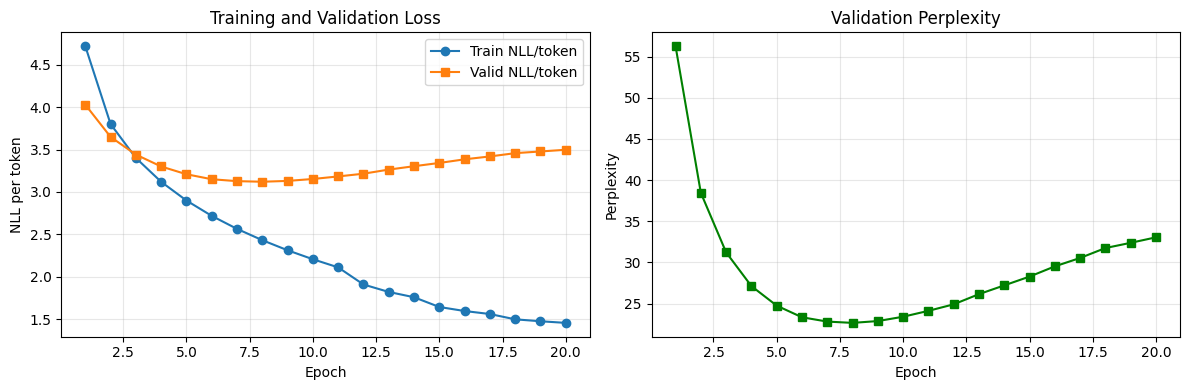

Saved: training_curves.png


In [21]:
import matplotlib.pyplot as plt

ep  = [h["epoch"]      for h in history]
trl = [h["train_loss"] for h in history]
vl  = [h["valid_loss"] for h in history]
vpp = [h["valid_ppl"]  for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep, trl, marker="o", label="Train NLL/token")
ax1.plot(ep, vl,  marker="s", label="Valid NLL/token")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("NLL per token")
ax1.set_title("Training and Validation Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, vpp, color="green", marker="s")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Perplexity")
ax2.set_title("Validation Perplexity")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

## 9. Decoding

**Greedy decoding** — pick the highest-probability token at each step (beam size = 1).

**Beam search** — maintain the top-*B* partial hypotheses.  
We apply **length normalisation**: score = log_prob / length^α  
(α = 0.6 by default). Without it, beam search systematically favours short sentences
because cumulative log-probabilities are always negative and grow in magnitude with length.

In [22]:
@torch.no_grad()
def greedy_translate(sentence, max_len=None):
    max_len  = max_len or config.max_decode_len
    model.eval()
    rev_src  = " ".join(normalize_text(sentence).split()[::-1])
    src_ids  = src_vocab.encode(rev_src, add_eos=True)
    src      = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
    src_lens = torch.tensor([len(src_ids)], dtype=torch.long, device=device)

    hidden = model.encode(src, src_lens)
    token  = torch.tensor([BOS_IDX], dtype=torch.long, device=device)
    out    = []

    for _ in range(max_len):
        logits, hidden = model.decoder.forward_step(token, hidden)
        token = logits.argmax(dim=-1)
        tid   = token.item()
        if tid == EOS_IDX: break
        out.append(tid)
    return tgt_vocab.decode(out)


@torch.no_grad()
def beam_translate(sentence, beam_size=None, max_len=None, alpha=None):
    beam_size = beam_size or config.beam_size
    max_len   = max_len   or config.max_decode_len
    alpha     = alpha     if alpha is not None else config.length_penalty_alpha
    model.eval()

    rev_src  = " ".join(normalize_text(sentence).split()[::-1])
    src_ids  = src_vocab.encode(rev_src, add_eos=True)
    src      = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
    src_lens = torch.tensor([len(src_ids)], dtype=torch.long, device=device)
    hidden   = model.encode(src, src_lens)

    def clone_h(h): return (h[0].clone(), h[1].clone())

    # beam item: (token_ids, raw_log_prob, hidden, last_token, finished)
    beams     = [([], 0.0, hidden, BOS_IDX, False)]
    completed = []

    for _ in range(max_len):
        candidates = []
        for ids, lp, h, last_tok, done in beams:
            if done:
                completed.append((ids, lp))
                candidates.append((ids, lp, h, last_tok, True))
                continue
            tok            = torch.tensor([last_tok], dtype=torch.long, device=device)
            logits, new_h  = model.decoder.forward_step(tok, h)
            log_p          = torch.log_softmax(logits, dim=-1)
            top_lp, top_ids = torch.topk(log_p, beam_size, dim=-1)
            for slp, sid in zip(top_lp[0], top_ids[0]):
                sid, slp = sid.item(), slp.item()
                new_lp   = lp + slp
                finished = (sid == EOS_IDX)
                candidates.append((
                    ids if finished else ids + [sid],
                    new_lp, clone_h(new_h), sid, finished
                ))

        # Sort by length-normalised score for pruning
        def norm_score(cand):
            ids, lp, *_ = cand
            length = max(len(ids), 1)
            return lp / (length ** alpha)

        beams = sorted(candidates, key=norm_score, reverse=True)[:beam_size]
        if all(b[4] for b in beams): break

    all_cands = completed + [(ids, lp) for ids, lp, *_ in beams]

    # Final ranking with length normalisation
    def final_score(cand):
        ids, lp = cand
        return lp / (max(len(ids), 1) ** alpha)

    best_ids, _ = max(all_cands, key=final_score)
    return tgt_vocab.decode(best_ids)

## 10. Qualitative Evaluation

In [23]:
print(f"{'─'*100}")
samples = random.sample(range(len(test_dataset)), min(10, len(test_dataset)))
for idx in samples:
    item = test_dataset[idx]
    pred = beam_translate(item["src_text"])
    print(f"EN : {item['src_text'][:90]}")
    print(f"REF: {item['tgt_text'][:90]}")
    print(f"OUT: {pred[:90]}")
    print()

────────────────────────────────────────────────────────────────────────────────────────────────────
EN : they have the best names , like terror behind the walls which , by the way is in an actual
REF: elles portent les meilleurs noms , comme terror behind the walls qui est en fait une vraie
OUT: ils ont <UNK> les <UNK> , comme les <UNK> , les <UNK> , la liberté de <UNK> et les <UNK> .

EN : and as little as a decade ago , the medical community thought of gender as a slate that co
REF: et il y a à peine une dizaine d'années , la communauté médicale considérait le genre comme
OUT: comme il n'y a pas eu de temps , il y a eu un âge de la vie sociale .

EN : i think it's conceivable that these data are used for mutual benefit .
REF: j'estime qu'il est concevable que ces données soient utilisées dans leur intérêt mutuel .
OUT: je pense qu'il est possible que ces données soient utilisées pour les <UNK> .

EN : row over closure of emergency unit at hôtel-dieu
REF: imbroglio autour de la ferme

## 11. BLEU Evaluation

BLEU measures n-gram overlap between model output and reference translations.
The paper reports BLEU = 34.81 on the *full* WMT'14 test set with 12M training pairs.
Our score will be lower due to the simplifications, which is expected and discussed in the report.

In [24]:
@torch.no_grad()
def compute_bleu(n_samples, use_beam=False):
    if not SACREBLEU_AVAILABLE:
        print("sacrebleu not available — run: !pip install sacrebleu")
        return None
    bleu  = BLEU(tokenize="none")
    refs, preds = [], []
    n = min(n_samples, len(test_dataset))
    for idx in range(n):
        item  = test_dataset[idx]
        pred  = beam_translate(item["src_text"]) if use_beam else greedy_translate(item["src_text"])
        refs.append(item["tgt_text"])
        preds.append(pred)
        if (idx + 1) % 200 == 0:
            print(f"  {idx+1}/{n} evaluated…")
    return bleu.corpus_score(preds, [refs]).score


print("Computing greedy BLEU…")
greedy_bleu = compute_bleu(config.bleu_eval_samples, use_beam=False)
print(f"  Greedy BLEU : {greedy_bleu:.2f}")

print("\nComputing beam BLEU…")
beam_bleu = compute_bleu(config.bleu_eval_samples, use_beam=True)
print(f"  Beam BLEU (B={config.beam_size}) : {beam_bleu:.2f}")

Computing greedy BLEU…
  200/1000 evaluated…
  400/1000 evaluated…
  600/1000 evaluated…
  800/1000 evaluated…


  1000/1000 evaluated…
  Greedy BLEU : 4.18

Computing beam BLEU…
  200/1000 evaluated…
  400/1000 evaluated…
  600/1000 evaluated…
  800/1000 evaluated…


  1000/1000 evaluated…
  Beam BLEU (B=5) : 4.70


## 12. Results Summary

In [25]:
print("=" * 62)
print("  EXPERIMENTAL RESULTS SUMMARY")
print("=" * 62)

rows = [
    ("Dataset",              "WMT'14 En→Fr (subset)"),
    ("Training pairs",       f"{len(train_pairs):,}"),
    ("Max sentence length",  config.max_src_len),
    ("Encoder layers",       config.num_layers),
    ("Embedding dim",        config.embed_dim),
    ("Hidden dim",           config.hidden_dim),
    ("Source vocab",         f"{len(src_vocab):,}"),
    ("Target vocab",         f"{len(tgt_vocab):,}"),
    ("Batch size",           config.batch_size),
    ("Optimizer",            "Adam"),
    ("Initial LR",           config.learning_rate),
    ("Gradient clip",        config.clip),
    ("Epochs trained",       config.num_epochs),
    ("", ""),
    ("Final train NLL",      f"{history[-1]['train_loss']:.4f}"),
    ("Best valid NLL",       f"{best_valid_loss:.4f}"),
    ("Best valid PPL",       f"{ppl(best_valid_loss):.1f}"),
    ("", ""),
    ("Greedy BLEU",          f"{greedy_bleu:.2f}"),
    (f"Beam BLEU (B={config.beam_size})", f"{beam_bleu:.2f}"),
    ("", ""),
    ("Paper BLEU (full scale)", "34.81"),
]

for k, v in rows:
    if k == "": print()
    else: print(f"  {k:<35} {v}")
print("=" * 62)

  EXPERIMENTAL RESULTS SUMMARY
  Dataset                             WMT'14 En→Fr (subset)
  Training pairs                      200,000
  Max sentence length                 35
  Encoder layers                      2
  Embedding dim                       512
  Hidden dim                          512
  Source vocab                        20,000
  Target vocab                        10,000
  Batch size                          128
  Optimizer                           Adam
  Initial LR                          0.001
  Gradient clip                       5.0
  Epochs trained                      20

  Final train NLL                     1.4541
  Best valid NLL                      3.1202
  Best valid PPL                      22.7

  Greedy BLEU                         4.18
  Beam BLEU (B=5)                     4.70

  Paper BLEU (full scale)             34.81
